<a href="https://colab.research.google.com/github/Ankabellam/ChatDev/blob/main/Housing_hackatan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***ML Hackton - House ***

Dataset Description :
Housing price dataset of Bengaluru city is provided as train dataset (train.csv). Along with the train dataset, two more external reference datasets (avg_rent.csv & dist_from_city_centre.csv ) is given for further feature engineering. **bold text**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')


In [6]:
from google.colab import files
uploaded = files.upload()


Saving avg_rent.csv to avg_rent (1).csv
Saving dist_from_city_centre.csv to dist_from_city_centre (1).csv
Saving sample_submission.csv to sample_submission (1).csv
Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


In [7]:
#Load the training data and test data sets.
avg_data = pd.read_csv('avg_rent.csv')
dist_data = pd.read_csv('dist_from_city_centre.csv')
sample_data = pd.read_csv('sample_submission.csv')
test_data = pd.read_csv('test.csv')
train_data = pd.read_csv('train.csv')



In [26]:
train_data.head()

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [27]:
# Check the missing values
train_data.isnull().sum()

,0
ID,0
area_type,0
availability,0
location,1
size,14
society,4428
total_sqft,0
bath,65
balcony,504
price,0


In [29]:
# fill Missing Values
train_data['balcony'].fillna(train_data['balcony'].median(), inplace=True)
train_data['bath'].fillna(train_data['bath'].median(), inplace=True)
train_data['location'].fillna(0, inplace=True)
train_data['size'].fillna(0, inplace=True)
train_data['society'].fillna(0, inplace=True)

train_data.head()

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,0,1440,2.0,3.0,62.00
3,3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,4,Super built-up Area,Ready To Move,Kothanur,2 BHK,0,1200,2.0,1.0,51.00


In [30]:
train_data.describe()

,ID,bath,balcony,price
count,10656.000000,10656.000000,10656.000000,10656.000000
mean,5327.500000,2.686374,1.601539,112.214256
std,3076.266568,1.349344,0.806597,142.231967
min,0.000000,1.000000,0.000000,8.000000
25%,2663.750000,2.000000,1.000000,50.000000
50%,5327.500000,2.000000,2.000000,72.000000
75%,7991.250000,3.000000,2.000000,120.000000
max,10655.000000,40.000000,3.000000,2700.000000


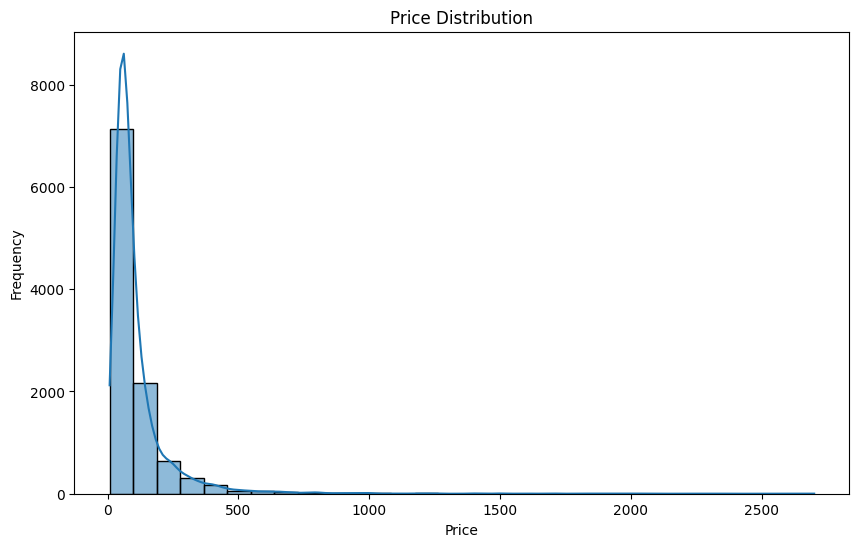

<function matplotlib.pyplot.show(close=None, block=None)>

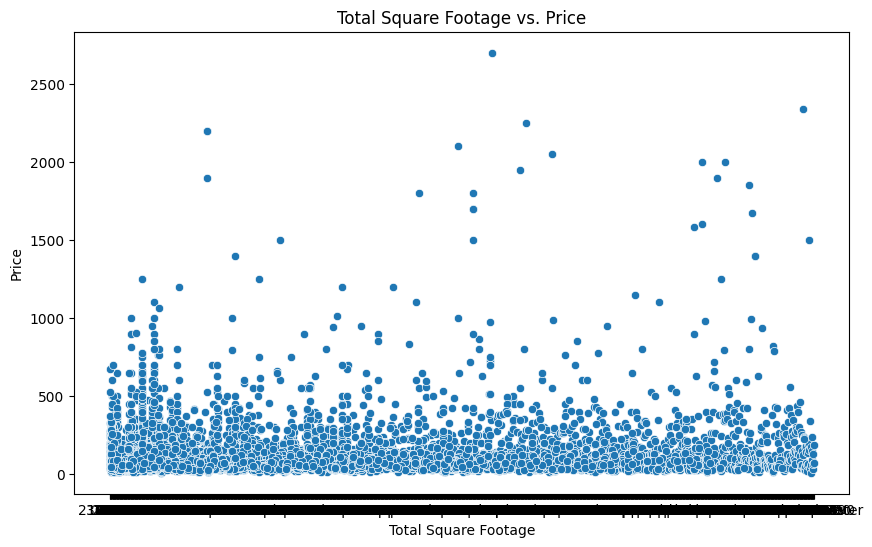

In [33]:
# visualizing Relationship
import seaborn as sns
import matplotlib.pyplot as plt

#plot price distribution
plt.figure(figsize=(10, 6))
sns.histplot(train_data['price'], bins=30, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Scatter plot between total_sqft and price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_sqft', y='price', data=train_data)
plt.title('Total Square Footage vs. Price')
plt.xlabel('Total Square Footage')
plt.ylabel('Price')
plt.show

In [41]:
print(train_data.columns)

Index(['ID', 'total_sqft', 'bath', 'balcony', 'price',
       'area_type_Carpet  Area', 'area_type_Plot  Area',
       'area_type_Super built-up  Area', 'availability_15-Aug',
       'availability_15-Dec',
       ...
       'society_WishiVa', 'society_WoarkEm', 'society_Xeitaa ',
       'society_YCnce R', 'society_Yaenti ', 'society_ZeodsWo',
       'society_Zonce E', 'society_Zostaa ', 'society_i1odsne',
       'society_i1rtsCo'],
      dtype='object', length=3677)


In [48]:
#Feature Engineering #####
from sklearn.preprocessing import StandardScaler
# Convert 'total_sqft' values to numeric
def convert_sqft_to_num(x):
  if isinstance(x, str):
    if '-' in x:
      tokens = x.split('-')
      if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
      return float(x)
    except ValueError:
      return None
  elif isinstance(x, float) or isinstance(x, int):
    return x
  else:
    return None

train_data['total_sqft'] = train_data['total_sqft'].apply(convert_sqft_to_num)
features_to_scale = ['total_sqft', 'bath', 'balcony']
scaler = StandardScaler()
train_data[features_to_scale] = scaler.fit_transform(train_data[features_to_scale])

In [51]:
# Building the linear regression Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = train_data.drop(['price'], axis=1)
y = train_data['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
#Trining the Model
# Check for missing values in X_train
#print(X_train.isnull().sum())

# Remove rows with any missing values from X_train and y_train
X_train_cleaned = X_train.dropna()
y_train_cleaned = y_train[X_train_cleaned.index]

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean') # Use mean imputation
X_test_imputed = imputer.fit_transform(X_test)

model = LinearRegression()
model.fit(X_train_cleaned, y_train_cleaned)
y_pred = model.predict(X_test_imputed)

#Caluclate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 3145066612.0282702


**MODEL** **EVALUATION**

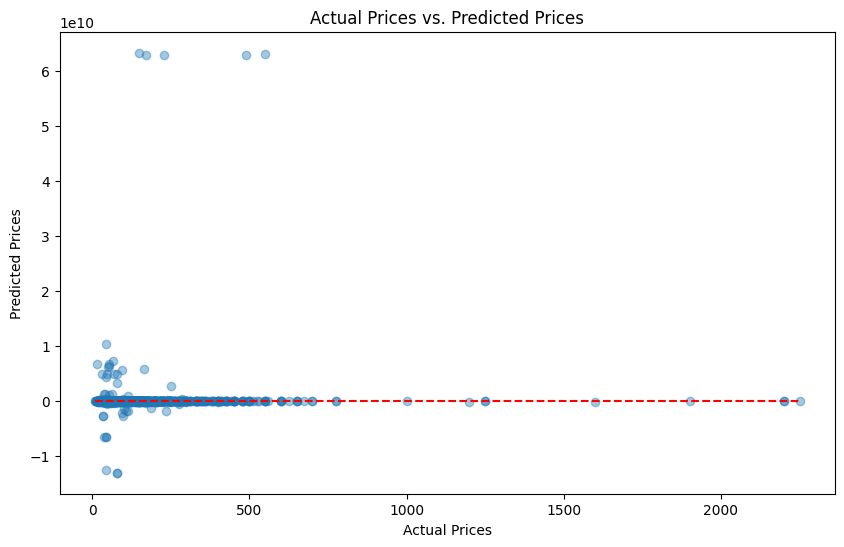

In [67]:
#Plotting preditction vs actual prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual Prices vs. Predicted Prices')
plt.show()


In [63]:
#Handling outliers
#Remove extream outliers in price (for example , properties priced above a threshold)
threshold = 1000000
train_data = train_data[train_data['price'] < 500]

In [90]:
#Making Predections on Test Set
#Prepare the test data (ensure same feature transformation as train)
print(test_data.isnull().sum())

test_data_cleaned = test_data.dropna()
#y_train_cleaned = y_test[test_data_cleaned.index]


X_test_cleaned = X_test.dropna()
y_test_cleaned = y_train[X_test_cleaned.index]

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean') # Use mean imputation
X_test_imputed = imputer.fit_transform(X_test)

model = LinearRegression()
model.fit(X_test_cleaned, y_test_cleaned)
y_pred = model.predict(X_test_imputed)

test_data['total_sqft'] = test_data['total_sqft'].apply(convert_sqft_to_num)

# Get the common columns between train and test data
common_columns = list(set(X_train_cleaned.columns) & set(test_data.columns))

# Select only the common columns from both train and test data
X_train_cleaned = X_train_cleaned[common_columns]
test_data = test_data[common_columns]

test_data[features_to_scale] = scaler.transform(test_data[features_to_scale])

test_predictions = model.predict(test_data)

sample_submission = pd.DataFrame({'Id': test_data['id'], 'price': test_predictions})
sample_submission.to_csv('sample_submission.csv', index=False)

balcony                           105
bath                                8
area_type_Super built-up  Area      0
area_type_Carpet  Area              0
ID                                  0
total_sqft                          6
dtype: int64


KeyError: "None of [Index([ 1350,  2012,  1965,  9800,   251,    33,  5563,  4121,  4793,   265,\n       ...\n        6502,  9395,  8551,  2487,  7700, 10563,  8743,  6447,  2232,  3032],\n      dtype='int64', length=2123)] are in the [index]"